<a href="https://colab.research.google.com/github/vadhan123/NLP/blob/main/LAB_4_2266.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME: G.vadhan
H.NO: 2403A52266
Batch NO: 10

In [ ]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import movie_reviews, stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
nltk.download('movie_reviews')
nltk.download('stopwords')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Load stopwords
stop_words = stopwords.words('english')
# Load positive and negative reviews
positive_reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids('pos')]
negative_reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids('neg')]
print(f"Positive reviews:{len(positive_reviews)}")
print(f"Negative reviews:{len(negative_reviews)}")

Positive reviews:1000
Negative reviews:1000


In [ ]:
vectorizer = TfidfVectorizer(
           lowercase=True,
           stop_words=stop_words,
           token_pattern=r'\b[a-zA-Z]{2,}\b',
           max_features=3000)

In [ ]:
tfidf_pos = vectorizer.fit_transform(positive_reviews)
pos_terms = vectorizer.get_feature_names_out()
pos_scores = tfidf_pos.mean(axis=0).A1

In [ ]:
tfidf_neg = vectorizer.fit_transform(negative_reviews)
neg_terms = vectorizer.get_feature_names_out()
neg_scores = tfidf_neg.mean(axis=0).A1

In [ ]:
def get_top_terms(terms,scores,n=15):
  df = pd.DataFrame({'term': terms,'score': scores})
  return df.sort_values(by='score', ascending=False).head(n)

top_pos = get_top_terms(pos_terms, pos_scores)
top_neg = get_top_terms(neg_terms, neg_scores)
print("Top Positive Terms:\n", top_pos)
print("\nTop Negative Terms:\n", top_neg)

Top Positive Terms:
             term     score
1003        film  0.069965
1768       movie  0.044635
1890         one  0.041694
1561        like  0.029416
2539       story  0.023972
1158        good  0.023685
1556        life  0.022936
2714        time  0.022707
78          also  0.022129
2917        well  0.022072
880         even  0.021183
421    character  0.021143
423   characters  0.020960
2795         two  0.020388
1774        much  0.020089

Top Negative Terms:
             term     score
991         film  0.066718
1756       movie  0.054488
1865         one  0.043225
1547        like  0.032201
865         even  0.025968
1140        good  0.024491
195          bad  0.023466
2701        time  0.023385
2977       would  0.022687
2524       story  0.022503
1112         get  0.022276
1763        much  0.021733
1986        plot  0.021122
423    character  0.020758
425   characters  0.020619


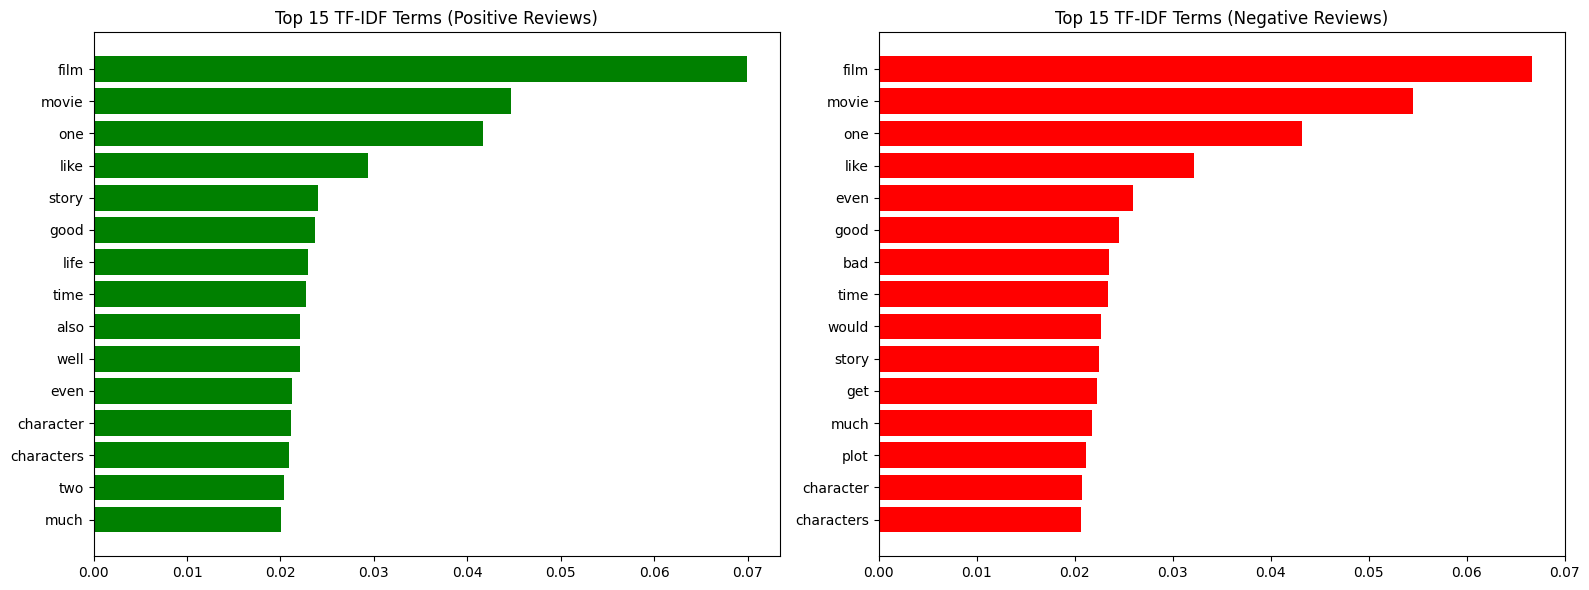

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Positive reviews plot
axes[0].barh(top_pos['term'], top_pos['score'], color='green')
axes[0].set_title("Top 15 TF-IDF Terms (Positive Reviews)")
axes[0].invert_yaxis()
# Negative reviews plot
axes[1].barh(top_neg['term'], top_neg['score'], color='red')
axes[1].set_title("Top 15 TF-IDF Terms (Negative Reviews)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Compare Common and unique terms
common_terms = set (pos_terms) & set (neg_terms)
unique_terms_pos = set(pos_terms) - common_terms
unique_terms_neg = set(neg_terms) - common_terms
print(f"Number of common terms:{len(common_terms)}")
print(f"Number of unique terms in positive reviews:{len(unique_terms_pos)}")
print(f"Number of unique terms in negative reviews:{len(unique_terms_neg)}")

Number of common terms:2348
Number of unique terms in positive reviews:652
Number of unique terms in negative reviews:652
